Full Dev Set: (456, 1004)
Training Set: (364, 1004)
Validation Set: (92, 1004)


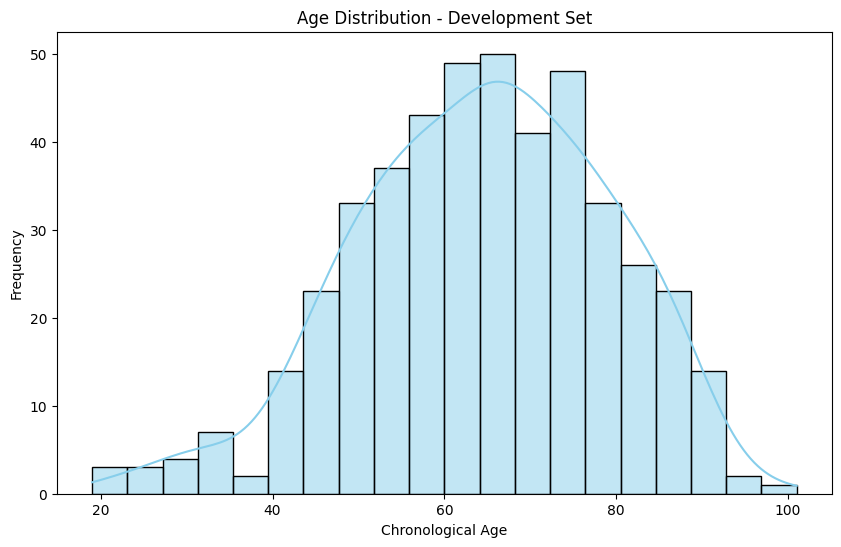

Preprocessing complete. Data is imputed, scaled, and encoded.


In [1]:
# %% [markdown]
# # Task 1: Data Exploration and Preprocessing
# This notebook explores the GSE40279 dataset and establishes the preprocessing pipeline.

# %%
!pip install matplotlib seaborn pandas scikit-learn
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Add src to path to import functions
sys.path.append('../src/')
from functions import load_dataset, split_data, get_preprocessing_pipeline

# %% [markdown]
# ## 1.1 Data Loading and Splitting
# Loading the development set and splitting it into 80% training and 20% validation.

# %%
df_dev = load_dataset('/Users/giorgos.boulogeorgos/Documents/mlcb_assignment1/data/development_data.csv')
train_df, val_df = split_data(df_dev, target_col='age', test_size=0.2, seed=42)

print(f"Full Dev Set: {df_dev.shape}")
print(f"Training Set: {train_df.shape}")
print(f"Validation Set: {val_df.shape}")

# %% [markdown]
# ## 1.3 Exploratory Analysis
# ### Dataset Statistics
# | Metric | Value |
# | :--- | :--- |
# | Age Mean | {train_df['age'].mean():.2f} |
# | Age Std | {train_df['age'].std():.2f} |
# | Age Range | {train_df['age'].min()} - {train_df['age'].max()} |
# | Sex Balance (M/F) | {train_df['sex'].value_counts().to_dict()} |

# %%
plt.figure(figsize=(10, 6))
sns.histplot(df_dev['age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution - Development Set')
plt.xlabel('Chronological Age')
plt.ylabel('Frequency')
plt.savefig('../figures/age_distribution.png', dpi=150)
plt.show()

# %% [markdown]
# ## 1.2 Preprocessing Pipeline
# We define CpG features and metadata features separately to construct different baselines later.

# %%
cpg_features = [col for col in df_dev.columns if col.startswith('cg')]
metadata_features = ['sex', 'ethnicity']

# Initialize the pipeline
preprocessor = get_preprocessing_pipeline(cpg_features, metadata_features)

# FIT ONLY ON TRAINING DATA
X_train_processed = preprocessor.fit_transform(train_df)
y_train = train_df['age'].values

# TRANSFORM VALIDATION DATA (NO FITTING)
X_val_processed = preprocessor.transform(val_df)
y_val = val_df['age'].values

print("Preprocessing complete. Data is imputed, scaled, and encoded.")